In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

In [31]:
dataset = pd.read_csv('../data/cleveland_clean.csv')
dataset.head()

,Age,Sex,Chest_Pain_Type,Resting_Blood_Pressure,Serum_Cholesterol,Fasting_Blood_Sugar,Resting_ECG,Max_Heart_Rate_Achieved,Exercise_Induced_Angina,ST_Depression,ST_Slope,Number_of_Major_Vessels,Thalassemia,Target_Diagnosis
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,A
1,37,1,3,130,250,0,0,187,0,3.5,3,0,3,A
2,41,0,2,130,204,0,2,172,0,1.4,1,0,3,A
3,56,1,2,120,236,0,0,178,0,0.8,1,0,3,A
4,57,0,4,120,354,0,0,163,1,0.6,1,0,3,A


In [32]:
# ==========================================
# 2. PREPROCESSING TARGET 
# ==========================================
dataset['Target_Encoded'] = dataset['Target_Diagnosis'].apply(lambda x: 0 if x == 'A' else 1)

print("\n--- Distribusi Target (0=Sehat, 1=Sakit) ---")
print(dataset['Target_Encoded'].value_counts())


--- Distribusi Target (0=Sehat, 1=Sakit) ---
Target_Encoded
0    164
1    139
Name: count, dtype: int64


In [33]:
X = dataset.drop(['Target_Diagnosis', 'Target_Encoded'], axis=1)
y = dataset['Target_Encoded']

# Inisialisasi Scaler
scaler = MinMaxScaler()

# Lakukan Scaling
X_scaled = scaler.fit_transform(X)

# Kembalikan ke DataFrame (Nama kolom otomatis mengikuti nama baru yang Bahasa Inggris)
X_scaled_dataset = pd.DataFrame(X_scaled, columns=X.columns)

# Cek Hasil Scaling
print("\n--- 5 Data Teratas Setelah Normalisasi ---")
from IPython.display import display
display(X_scaled_dataset.head())


--- 5 Data Teratas Setelah Normalisasi ---


,Age,Sex,Chest_Pain_Type,Resting_Blood_Pressure,Serum_Cholesterol,Fasting_Blood_Sugar,Resting_ECG,Max_Heart_Rate_Achieved,Exercise_Induced_Angina,ST_Depression,ST_Slope,Number_of_Major_Vessels,Thalassemia
0,0.708333,1.0,0.000000,0.481132,0.244292,1.0,1.0,0.603053,0.0,0.370968,1.0,0.0,0.75
1,0.166667,1.0,0.666667,0.339623,0.283105,0.0,0.0,0.885496,0.0,0.564516,1.0,0.0,0.00
2,0.250000,0.0,0.333333,0.339623,0.178082,0.0,1.0,0.770992,0.0,0.225806,0.0,0.0,0.00
3,0.562500,1.0,0.333333,0.245283,0.251142,0.0,0.0,0.816794,0.0,0.129032,0.0,0.0,0.00
4,0.583333,0.0,1.000000,0.245283,0.520548,0.0,0.0,0.702290,1.0,0.096774,0.0,0.0,0.00


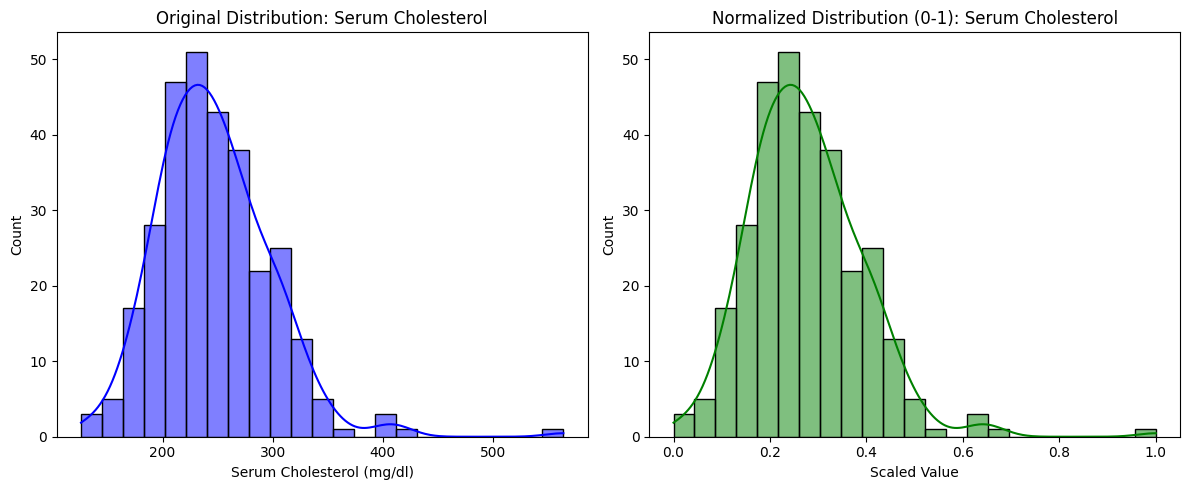

In [34]:
# ==========================================
# 4. VISUALISASI HASIL 
# ==========================================
plt.figure(figsize=(12, 5))

# Plot 1: Data Asli (Sebelum Normalisasi)
plt.subplot(1, 2, 1)
# Menggunakan nama kolom baru: 'Serum_Cholesterol'
sns.histplot(dataset['Serum_Cholesterol'], kde=True, color='blue') 
plt.title('Original Distribution: Serum Cholesterol')
plt.xlabel('Serum Cholesterol (mg/dl)')

# Plot 2: Data Setelah Normalisasi (MinMax Scaler)
plt.subplot(1, 2, 2)
# Menggunakan nama kolom baru: 'Serum_Cholesterol'
sns.histplot(X_scaled_dataset['Serum_Cholesterol'], kde=True, color='green')
plt.title('Normalized Distribution (0-1): Serum Cholesterol')
plt.xlabel('Scaled Value')

plt.tight_layout()
plt.show()


--- Feature Relevance Ranking (Correlation with Diagnosis) ---
Thalassemia                0.528962
Number_of_Major_Vessels    0.464167
Exercise_Induced_Angina    0.431894
ST_Depression              0.424510
Max_Heart_Rate_Achieved    0.417167
Chest_Pain_Type            0.414446
ST_Slope                   0.339213
Sex                        0.276816
Age                        0.223120
Resting_ECG                0.169202
Resting_Blood_Pressure     0.150825
Serum_Cholesterol          0.085164
Fasting_Blood_Sugar        0.025264
Name: Target_Encoded, dtype: float64


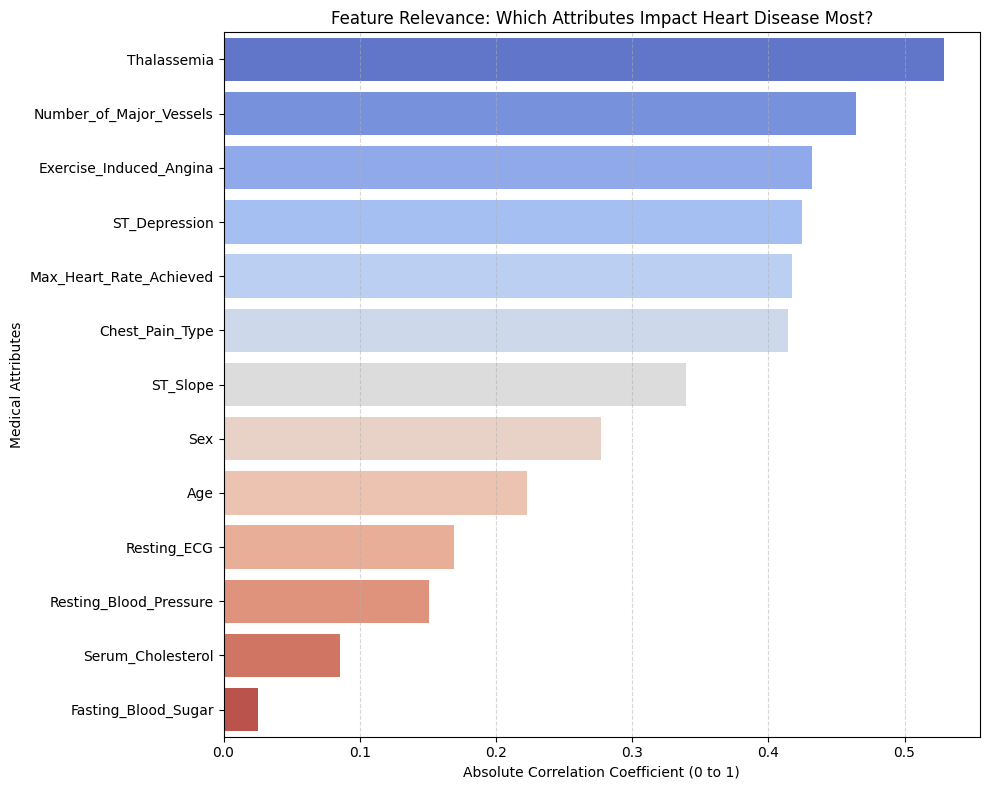

In [35]:
# ==========================================
# 7. ANALISIS RELEVANSI FITUR (FEATURE RELEVANCE)
# ==========================================
# Gabungkan fitur yang sudah dinormalisasi (X) dengan target (y)
df_analysis = pd.concat([X_scaled_dataset, y], axis=1)

# Hitung Matriks Korelasi
correlation_matrix = df_analysis.corr()

# Fokus hanya pada korelasi terhadap 'Target_Encoded'
# Kita drop 'Target_Encoded' itu sendiri karena korelasinya pasti 1.0
target_corr = correlation_matrix['Target_Encoded'].drop('Target_Encoded')

# Urutkan berdasarkan Kekuatan Hubungan (Nilai Absolut)
# Absolut berarti: Korelasi -0.8 (Negatif Kuat) sama pentingnya dengan 0.8 (Positif Kuat)
relevance = target_corr.abs().sort_values(ascending=False)

print("\n--- Feature Relevance Ranking (Correlation with Diagnosis) ---")
print(relevance)

# Visualisasi Bar Chart
plt.figure(figsize=(10, 8))

# Tips: Tambahkan hue=relevance.index dan legend=False agar warna muncul tanpa warning di Seaborn terbaru
sns.barplot(
    x=relevance.values, 
    y=relevance.index, 
    hue=relevance.index, 
    palette='coolwarm', 
    legend=False
)

plt.title('Feature Relevance: Which Attributes Impact Heart Disease Most?')
plt.xlabel('Absolute Correlation Coefficient (0 to 1)')
plt.ylabel('Medical Attributes')
plt.grid(axis='x', linestyle='--', alpha=0.5) # Garis bantu tipis
plt.tight_layout()
plt.show()

In [36]:
# ==========================================
# 6A. FEATURE SELECTION: HAPUS FITUR TIDAK RELEVAN
# ==========================================
# 1. Gabungkan sementara X (Fitur Medis) dan y (Diagnosis) untuk hitung korelasi
# X_scaled_dataset sekarang sudah berisi nama kolom bahasa Inggris (Age, Sex, dll)
df_analysis = pd.concat([X_scaled_dataset, y], axis=1)

# 2. Hitung korelasi terhadap Target_Encoded
correlation_matrix = df_analysis.corr()

# Ambil nilai korelasi target, dan ambil nilai absolutnya
target_corr = correlation_matrix['Target_Encoded'].drop('Target_Encoded').abs()

# 3. Tentukan Batas Minimal (Threshold)
# Angka 0.05 artinya: Hubungan < 5% dianggap kebetulan/noise.
threshold_relevance = 0.05 

# 4. Cari fitur yang nilainya di bawah threshold
irrelevant_features = target_corr[target_corr < threshold_relevance].index.tolist()

print(f"Threshold Relevansi: {threshold_relevance}")
print("\n--- Peringkat Relevansi Fitur (Correlation to Diagnosis) ---")
print(target_corr.sort_values(ascending=False))

# 5. Eksekusi Penghapusan
if len(irrelevant_features) > 0:
    print(f"\n[!] DITEMUKAN FITUR LEMAH (< {threshold_relevance}):")
    print(f"    -> {irrelevant_features}")
    
    # Hapus dari dataset utama
    X_scaled_dataset = X_scaled_dataset.drop(columns=irrelevant_features)
    print("Fitur tersebut BERHASIL DIHAPUS otomatis untuk efisiensi model.")
else:
    print("\nSemua fitur memiliki relevansi medis yang cukup (Tidak ada yang dihapus).")

print(f"\nSisa Fitur ({len(X_scaled_dataset.columns)}):")
print(X_scaled_dataset.columns.tolist())

Threshold Relevansi: 0.05

--- Peringkat Relevansi Fitur (Correlation to Diagnosis) ---
Thalassemia                0.528962
Number_of_Major_Vessels    0.464167
Exercise_Induced_Angina    0.431894
ST_Depression              0.424510
Max_Heart_Rate_Achieved    0.417167
Chest_Pain_Type            0.414446
ST_Slope                   0.339213
Sex                        0.276816
Age                        0.223120
Resting_ECG                0.169202
Resting_Blood_Pressure     0.150825
Serum_Cholesterol          0.085164
Fasting_Blood_Sugar        0.025264
Name: Target_Encoded, dtype: float64

[!] DITEMUKAN FITUR LEMAH (< 0.05):
    -> ['Fasting_Blood_Sugar']
Fitur tersebut BERHASIL DIHAPUS otomatis untuk efisiensi model.

Sisa Fitur (12):
['Age', 'Sex', 'Chest_Pain_Type', 'Resting_Blood_Pressure', 'Serum_Cholesterol', 'Resting_ECG', 'Max_Heart_Rate_Achieved', 'Exercise_Induced_Angina', 'ST_Depression', 'ST_Slope', 'Number_of_Major_Vessels', 'Thalassemia']


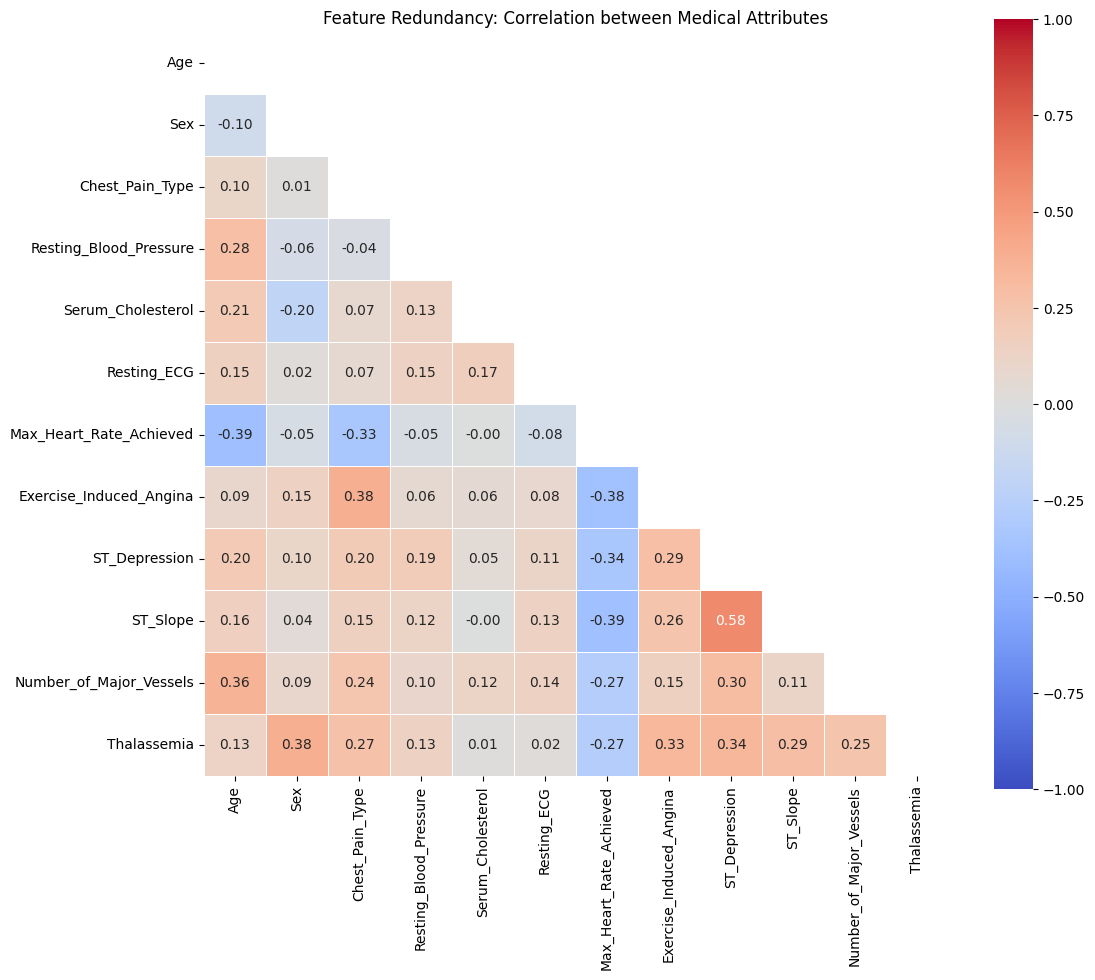


[2] Deteksi Redundansi (Threshold > 0.8):
AMAN. Tidak ditemukan atribut medis yang saling duplikat (redundant).


In [37]:
# ==========================================
# 6B. FEATURE REDUNDANCY (Cek Fitur Kembar)
# ==========================================
# 1. Visualisasi Heatmap
plt.figure(figsize=(12, 10))

# Buat mask untuk menutupi bagian atas segitiga (agar tidak pusing lihat angka dobel)
mask = np.triu(np.ones_like(X_scaled_dataset.corr(), dtype=bool))

sns.heatmap(X_scaled_dataset.corr(), 
            mask=mask,             
            annot=True,            # Tampilkan angka
            fmt=".2f",             # 2 angka desimal
            cmap='coolwarm',       # Merah (Positif) - Biru (Negatif)
            vmin=-1, vmax=1,       
            square=True, 
            linewidths=.5)

plt.title('Feature Redundancy: Correlation between Medical Attributes')
plt.show()

# 2. Cek Otomatis Pasangan Redundan 
# Jika korelasi > 0.80, berarti dua fitur itu membawa informasi yang hampir sama.
threshold_redundancy = 0.8
print(f"\n[2] Deteksi Redundansi (Threshold > {threshold_redundancy}):")

redundant_pairs = []
features = X_scaled_dataset.columns
corr_matrix = X_scaled_dataset.corr().abs()

for i in range(len(features)):
    for j in range(i+1, len(features)):
        if corr_matrix.iloc[i, j] > threshold_redundancy:
            pair = (features[i], features[j], corr_matrix.iloc[i, j])
            redundant_pairs.append(pair)

# 3. Keputusan
if len(redundant_pairs) > 0:
    print("DITEMUKAN FITUR REDUNDAN (Saran: Buang salah satu):")
    for f1, f2, score in redundant_pairs:
        print(f"- {f1} <--> {f2} (Korelasi: {score:.2f})")
    print(f"Tips: Cek Feature Relevance di atas. Pertahankan yang skornya lebih tinggi terhadap Target.")
else:
    print("AMAN. Tidak ditemukan atribut medis yang saling duplikat (redundant).")

In [38]:
# ==========================================
# PEMBERSIHAN KHUSUS: 
# ==========================================

# Daftar kolom yang MUNGKIN ingin dibuang (berdasarkan hasil Redundansi di atas)
# Jika langkah 6B bilang "AMAN", biarkan list ini kosong atau biarkan kode ini berjalan (errors='ignore')
cols_to_drop = [] 

# [OPSIONAL] Jika tadi ditemukan pasangan redundan, masukkan nama kolom yang mau dibuang ke sini.
# Contoh: cols_to_drop = ['ST_Slope'] 

if len(cols_to_drop) > 0:
    X_scaled_dataset = X_scaled_dataset.drop(columns=cols_to_drop, errors='ignore')
    print(f"Kolom berikut berhasil dibuang manual: {cols_to_drop}")
else:
    print("ℹTidak ada penghapusan kolom manual yang dilakukan.")

print("\n--- Daftar Kolom Final untuk Model Decision Tree ---")
print(X_scaled_dataset.columns.tolist())

ℹTidak ada penghapusan kolom manual yang dilakukan.

--- Daftar Kolom Final untuk Model Decision Tree ---
['Age', 'Sex', 'Chest_Pain_Type', 'Resting_Blood_Pressure', 'Serum_Cholesterol', 'Resting_ECG', 'Max_Heart_Rate_Achieved', 'Exercise_Induced_Angina', 'ST_Depression', 'ST_Slope', 'Number_of_Major_Vessels', 'Thalassemia']


In [40]:
# ==========================================
# 8. SIMPAN DATA FINAL (EXPORT)
# ==========================================
# 1. Gabungkan Fitur (X) yang sudah dinormalisasi dan Target (y)
dataset_final = pd.concat([X_scaled_dataset, y], axis=1)

output_path = '../data/cleveland_normalized.csv'

# 3. Simpan ke CSV 
dataset_final.to_csv(output_path, index=False)

# 4. Laporan Sukses & Verifikasi
print(f"\n SUKSES! File berhasil disimpan ke: {output_path}")
print(f" Dimensi Akhir: {dataset_final.shape} (Baris, Kolom)")

print("\n--- Daftar Kolom Final (English Medical Terms) ---")
print(dataset_final.columns.tolist())

print("\n--- Preview Data Final (Siap Masuk Model) ---")
from IPython.display import display
display(dataset_final.head())


 SUKSES! File berhasil disimpan ke: ../data/cleveland_normalized.csv
 Dimensi Akhir: (303, 13) (Baris, Kolom)

--- Daftar Kolom Final (English Medical Terms) ---
['Age', 'Sex', 'Chest_Pain_Type', 'Resting_Blood_Pressure', 'Serum_Cholesterol', 'Resting_ECG', 'Max_Heart_Rate_Achieved', 'Exercise_Induced_Angina', 'ST_Depression', 'ST_Slope', 'Number_of_Major_Vessels', 'Thalassemia', 'Target_Encoded']

--- Preview Data Final (Siap Masuk Model) ---


,Age,Sex,Chest_Pain_Type,Resting_Blood_Pressure,Serum_Cholesterol,Resting_ECG,Max_Heart_Rate_Achieved,Exercise_Induced_Angina,ST_Depression,ST_Slope,Number_of_Major_Vessels,Thalassemia,Target_Encoded
0,0.708333,1.0,0.000000,0.481132,0.244292,1.0,0.603053,0.0,0.370968,1.0,0.0,0.75,0
1,0.166667,1.0,0.666667,0.339623,0.283105,0.0,0.885496,0.0,0.564516,1.0,0.0,0.00,0
2,0.250000,0.0,0.333333,0.339623,0.178082,1.0,0.770992,0.0,0.225806,0.0,0.0,0.00,0
3,0.562500,1.0,0.333333,0.245283,0.251142,0.0,0.816794,0.0,0.129032,0.0,0.0,0.00,0
4,0.583333,0.0,1.000000,0.245283,0.520548,0.0,0.702290,1.0,0.096774,0.0,0.0,0.00,0
